In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('zuu crew scores.csv')
df.head(5)

,MemberName,EducationLevel,Attendance,TotalHours,AssignmentsCompleted,HackathonParticipation,GitHubScore,PeerReviewScore,CourseName,CapstoneScore
0,Theekshana Rathnayake,3,79.9,43.7,2,0,62.8,5.0,Foundations of ML,45.3
1,Mayura Sandakalum Sellapperuma,2,76.8,95.6,6,0,87.4,2.7,Foundations of ML,78.8
2,Amila Narangoda,3,96.6,75.9,8,0,98.4,2.8,Foundations of ML,65.4
3,Nisal Gamage,1,74.5,63.9,7,0,76.8,1.7,Production-Ready ML Systems,100.0
4,Tharusha Vihanga,2,83.2,24.0,6,0,41.8,4.2,Foundations of ML,40.1


In [4]:
df = df[df['CourseName'] == 'Foundations of ML']
df.head()

,MemberName,EducationLevel,Attendance,TotalHours,AssignmentsCompleted,HackathonParticipation,GitHubScore,PeerReviewScore,CourseName,CapstoneScore
0,Theekshana Rathnayake,3,79.9,43.7,2,0,62.8,5.0,Foundations of ML,45.3
1,Mayura Sandakalum Sellapperuma,2,76.8,95.6,6,0,87.4,2.7,Foundations of ML,78.8
2,Amila Narangoda,3,96.6,75.9,8,0,98.4,2.8,Foundations of ML,65.4
4,Tharusha Vihanga,2,83.2,24.0,6,0,41.8,4.2,Foundations of ML,40.1
7,Chamath Perera,3,86.5,88.0,5,0,23.9,1.3,Foundations of ML,68.2


In [5]:
X = df[ 'TotalHours' ].values.reshape(-1, 1)
Y = df[ 'CapstoneScore' ].values

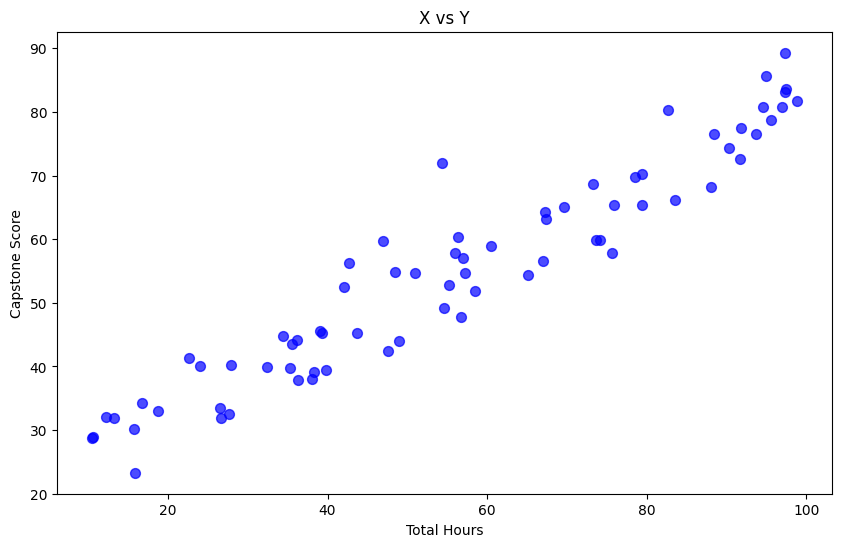

In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, alpha=0.7, color='blue', s=50)
plt.xlabel('Total Hours')
plt.ylabel('Capstone Score')
plt.title('X vs Y')
plt.show()

In [7]:
def compute_cost(X, Y, beta):
    """ 
        X : (m, n)
        Y : (m, )
        beta : (beta0, beta1)

        MSE = >  sum(( y_hat - y ) ** 2)
        X.dot(beta) => beta0 + beta1.x1 + ...... + betaj.xj + ...... + betan.xn   
    """

    m= len(Y)
    y_hat = X.dot(beta)
    cost = ( 1 / (2 * m) ) * np.sum((y_hat - Y) ** 2)
    return cost

def gradient_descent(X, Y, beta, lr, n_iter):
    """ 
    X : (m, n) -> after adding bias : (m, n+1) -> (72, 2) | If I take transpose -> (2, 72)

    dj/dbetaj = (1 / m) * X.T * (y_hat - y)
    """

    m = len(Y)
    cost_history = []

    for i in range(n_iter):

        y_hat = X.dot(beta)
        gradients = (1 / m) * X.T.dot(y_hat - Y)

        beta = beta - lr * gradients
        cost = compute_cost(X, Y, beta)
        cost_history.append(cost)

        if i % 100 == 0:
            print(f"Iteration: {i}: cost: {cost:.4f} ")

    return cost_history,beta     

In [8]:
""" 
    y_hat = beta0.x0 + beta1.x1; xo = 1
    X = [1, x1]

"""


X_with_bias = np.column_stack([np.ones((len(X))), X])
X_with_bias

array([[ 1. , 43.7],
       [ 1. , 95.6],
       [ 1. , 75.9],
       [ 1. , 24. ],
       [ 1. , 88. ],
       [ 1. , 97.3],
       [ 1. , 26.5],
       [ 1. , 57.2],
       [ 1. , 48.9],
       [ 1. , 36.2],
       [ 1. , 65.1],
       [ 1. , 22.6],
       [ 1. , 36.3],
       [ 1. , 51. ],
       [ 1. , 56.3],
       [ 1. , 15.9],
       [ 1. , 96.9],
       [ 1. , 18.8],
       [ 1. , 54.6],
       [ 1. , 91.8],
       [ 1. , 69.6],
       [ 1. , 38.1],
       [ 1. , 26.6],
       [ 1. , 97.3],
       [ 1. , 94.6],
       [ 1. , 27.6],
       [ 1. , 39.3],
       [ 1. , 34.4],
       [ 1. , 42.1],
       [ 1. , 35.3],
       [ 1. , 98.8],
       [ 1. , 27.9],
       [ 1. , 10.5],
       [ 1. , 73.6],
       [ 1. , 75.6],
       [ 1. , 79.4],
       [ 1. , 16.7],
       [ 1. , 39.8],
       [ 1. , 15.7],
       [ 1. , 67.4],
       [ 1. , 74.2],
       [ 1. , 78.5],
       [ 1. , 60.5],
       [ 1. , 79.4],
       [ 1. , 54.4],
       [ 1. , 57. ],
       [ 1. , 48.5],
       [ 1. ,

In [9]:
beta = np.random.randn(2)
print(f"beta values : {beta}")

lr = 0.000001
n_iter = 10000

beta values : [0.45655966 0.87037469]


In [10]:
cost_history, beta = gradient_descent(X_with_bias, Y, beta, lr, n_iter)

Iteration: 0: cost: 52.7885 
Iteration: 100: cost: 51.3435 
Iteration: 200: cost: 50.6747 
Iteration: 300: cost: 50.3647 
Iteration: 400: cost: 50.2207 
Iteration: 500: cost: 50.1534 
Iteration: 600: cost: 50.1215 
Iteration: 700: cost: 50.1060 
Iteration: 800: cost: 50.0981 
Iteration: 900: cost: 50.0938 
Iteration: 1000: cost: 50.0910 
Iteration: 1100: cost: 50.0890 
Iteration: 1200: cost: 50.0873 
Iteration: 1300: cost: 50.0858 
Iteration: 1400: cost: 50.0844 
Iteration: 1500: cost: 50.0830 
Iteration: 1600: cost: 50.0816 
Iteration: 1700: cost: 50.0802 
Iteration: 1800: cost: 50.0789 
Iteration: 1900: cost: 50.0775 
Iteration: 2000: cost: 50.0761 
Iteration: 2100: cost: 50.0748 
Iteration: 2200: cost: 50.0734 
Iteration: 2300: cost: 50.0720 
Iteration: 2400: cost: 50.0707 
Iteration: 2500: cost: 50.0693 
Iteration: 2600: cost: 50.0679 
Iteration: 2700: cost: 50.0666 
Iteration: 2800: cost: 50.0652 
Iteration: 2900: cost: 50.0638 
Iteration: 3000: cost: 50.0625 
Iteration: 3100: cos

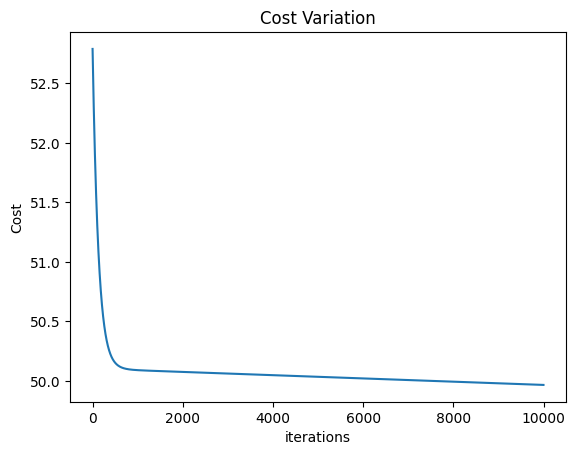

In [11]:
plt.plot(cost_history)
plt.title("Cost Variation")
plt.xlabel("iterations")
plt.ylabel("Cost")
plt.show()

In [12]:
print(f"beat beta : {beta}")

beat beta : [0.49404681 0.90732459]


In [13]:
x_min, x_max = float(np.min(X)), float(np.max(X))
x_interval = np.linspace(x_min, x_max, 100)
x_interval_with_bias = np.column_stack([np.ones((len(x_interval))), x_interval])
y_hat_interval = x_interval_with_bias.dot(beta)
y_hat_interval

array([10.02095501, 10.83021522, 11.63947544, 12.44873565, 13.25799587,
       14.06725608, 14.8765163 , 15.68577651, 16.49503673, 17.30429694,
       18.11355716, 18.92281738, 19.73207759, 20.54133781, 21.35059802,
       22.15985824, 22.96911845, 23.77837867, 24.58763888, 25.3968991 ,
       26.20615931, 27.01541953, 27.82467974, 28.63393996, 29.44320017,
       30.25246039, 31.06172061, 31.87098082, 32.68024104, 33.48950125,
       34.29876147, 35.10802168, 35.9172819 , 36.72654211, 37.53580233,
       38.34506254, 39.15432276, 39.96358297, 40.77284319, 41.58210341,
       42.39136362, 43.20062384, 44.00988405, 44.81914427, 45.62840448,
       46.4376647 , 47.24692491, 48.05618513, 48.86544534, 49.67470556,
       50.48396577, 51.29322599, 52.10248621, 52.91174642, 53.72100664,
       54.53026685, 55.33952707, 56.14878728, 56.9580475 , 57.76730771,
       58.57656793, 59.38582814, 60.19508836, 61.00434857, 61.81360879,
       62.62286901, 63.43212922, 64.24138944, 65.05064965, 65.85

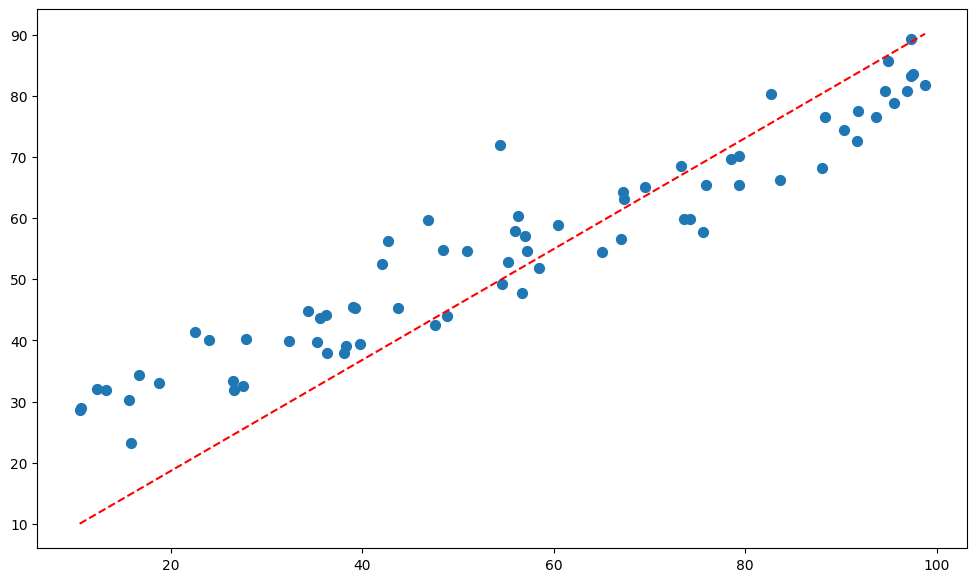

In [14]:
plt.figure(figsize=(12, 7))

plt.scatter(X, Y, s=50, label="actual data")

plt.plot(x_interval, y_hat_interval, 'r--', label="fitted line")

plt.show()

##### how to evaluate ?

    - MSE : Mean squared error
    - RMSE : Root mean squared error
    - MAE : Mean absolute error
    - R^2 : R-squared